In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical  # <-- Added


In [19]:
# --- Load CIFAR-10 data ---
(x_train, y_train), (x_test, y_test) = cifar10.load_data()  # <-- Include labels now
# the link for the dataset is: https://www.cs.toronto.edu/~kriz/cifar.html

# --- Normalize images to [0,1] ---
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# --- One-hot encode labels for classifier ---
num_classes = 10  # CIFAR-10 has 10 classes
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print('Train:', x_train.shape, 'Test:', x_test.shape)

Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


In [20]:
# # --- Encoder ---
# input_img = Input(shape=(32, 32, 3))
# x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
# x = MaxPooling2D((2,2), padding='same')(x)
# x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
# x = MaxPooling2D((2,2), padding='same')(x)
# x = Conv2D(8, (3,3), activation='relu', padding='same')(x)
# encoded = MaxPooling2D((2,2), padding='same', name='latent_space')(x)  # shape: (4, 4, 8)

# # Save encoder output for reuse
# latent_output = encoded

# # --- Decoder (for reconstruction) ---
# x = Conv2D(8, (3,3), activation='relu', padding='same')(encoded)
# x = UpSampling2D((2,2))(x)
# x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
# x = UpSampling2D((2,2))(x)
# x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
# x = UpSampling2D((2,2))(x)
# decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same', name='reconstruction')(x)

# # --- Classification Head (added) ---
# flat = Flatten()(latent_output)
# fc1 = Dense(128, activation='relu')(flat)
# class_output = Dense(num_classes, activation='softmax', name='classification')(fc1)

# # --- Multi-output Model ---
# from tensorflow.keras.models import Model

# model = Model(inputs=input_img, outputs=[decoded, class_output])
# model.compile(
#     optimizer='adam',
#     loss={'reconstruction': 'mse', 'classification': 'categorical_crossentropy'},
#     loss_weights={'reconstruction': 1.0, 'classification': 1.0},
#     metrics={'classification': 'accuracy'}
# )

# model.summary()

from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

# --- Parameters ---
input_shape = (32, 32, 3)
num_classes = 10  # Adjust based on your dataset
reconstruction_weight = 1.0
classification_weight = 1.0
label_smoothing = 0.1  # helps reduce overfitting

# --- Encoder ---
input_img = Input(shape=input_shape)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same', name='latent_space')(x)  # (4, 4, 8)

# Save encoder output for reuse
latent_output = encoded

# --- Decoder (Reconstruction) ---
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same', name='reconstruction')(x)

# --- Classification Head ---
flat = Flatten()(latent_output)
fc1 = Dense(128, activation='relu')(flat)
class_output = Dense(num_classes, activation='softmax', name='classification')(fc1)

# --- Combined Model ---
model = Model(inputs=input_img, outputs=[decoded, class_output])

# --- Loss Functions ---
classification_loss_fn = CategoricalCrossentropy(label_smoothing=label_smoothing)

# --- Compile ---
model.compile(
    optimizer=Adam(),
    loss={
        'reconstruction': 'mse',
        'classification': classification_loss_fn
    },
    loss_weights={
        'reconstruction': reconstruction_weight,
        'classification': classification_weight
    },
    metrics={
        'classification': 'accuracy'
    }
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │      4,624 │ max_pooling2d_2[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 16)  │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 8)   │      1,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 4, 4, 8)   │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 4, 4, 8)   │        584 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 8, 8, 8)   │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 8, 8, 16)  │      1,168 │ up_sampling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 16, 16,    │          0 │ conv2d_10[0][0]   │
│ (UpSampling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │      4,640 │ up_sampling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 128)       │          0 │ latent_space[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_5     │ (None, 32, 32,    │          0 │ conv2d_11[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 32, 32, 3) │        867 │ up_sampling2d_5[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,741 (123.99 KB)

 Trainable params: 31,741 (123.99 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # --- Train the multi-output model ---
# history = model.fit(
#     x_train, {'reconstruction': x_train, 'classification': y_train_cat},
#     epochs=45,
#     batch_size=128,
#     shuffle=True,
#     validation_split=0.1,
#     callbacks=[early_stop]
# )

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# --- One-hot encode labels (if not already done) ---
y_train_cat = to_categorical(y_train, num_classes=num_classes)

# --- Early stopping ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# --- Train the model ---
history = model.fit(
    x_train,
    {'reconstruction': x_train, 'classification': y_train_cat},
    validation_split=0.1,
    epochs=25,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/25
352/352 - 15s - 42ms/step - classification_accuracy: 0.3685 - classification_loss: 1.8616 - loss: 1.8970 - reconstruction_loss: 0.0352 - val_classification_accuracy: 0.4602 - val_classification_loss: 1.6782 - val_loss: 1.6931 - val_reconstruction_loss: 0.0265
Epoch 2/25
352/352 - 11s - 31ms/step - classification_accuracy: 0.4834 - classification_loss: 1.6299 - loss: 1.6556 - reconstruction_loss: 0.0254 - val_classification_accuracy: 0.5252 - val_classification_loss: 1.5705 - val_loss: 1.5814 - val_reconstruction_loss: 0.0247
Epoch 3/25
352/352 - 11s - 31ms/step - classification_accuracy: 0.5218 - classification_loss: 1.5556 - loss: 1.5794 - reconstruction_loss: 0.0235 - val_classification_accuracy: 0.5452 - val_classification_loss: 1.5211 - val_loss: 1.5285 - val_reconstruction_loss: 0.0222
Epoch 4/25
352/352 - 11s - 30ms/step - classification_accuracy: 0.5477 - classification_loss: 1.5031 - loss: 1.5262 - reconstruction_loss: 0.0229 - val_classification_accuracy: 0.5576 - v

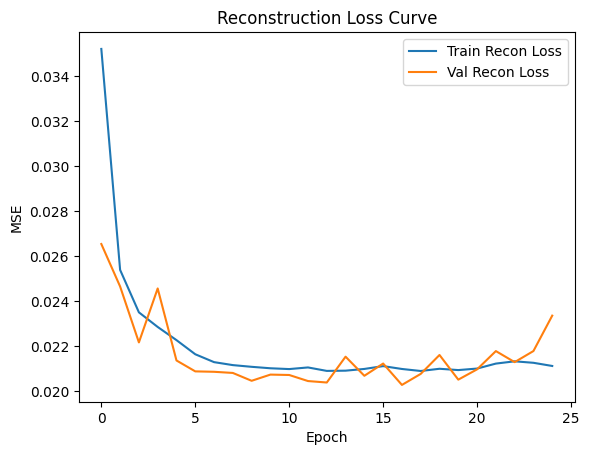

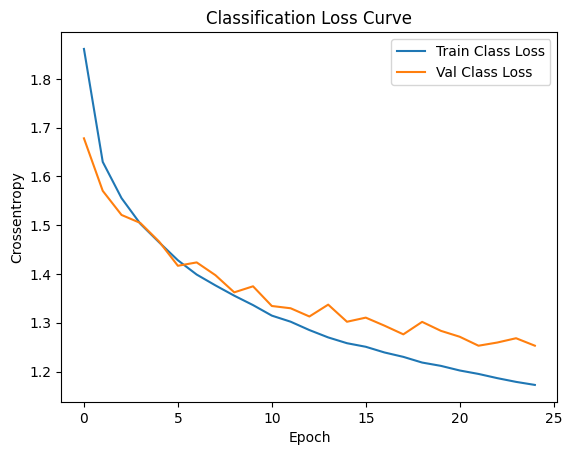

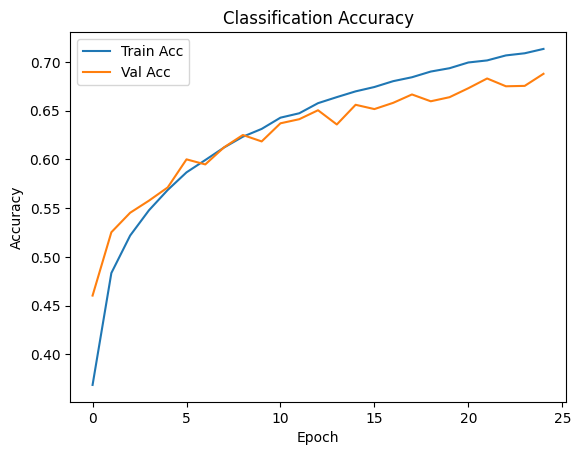

In [22]:
# --- Plot Reconstruction Loss ---
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.legend()
plt.title('Reconstruction Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()

# --- Plot Classification Loss ---
plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.legend()
plt.title('Classification Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Crossentropy')
plt.show()

# --- Optional: Accuracy Curve ---
plt.figure()
plt.plot(history.history['classification_accuracy'], label='Train Acc')
plt.plot(history.history['val_classification_accuracy'], label='Val Acc')
plt.legend()
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


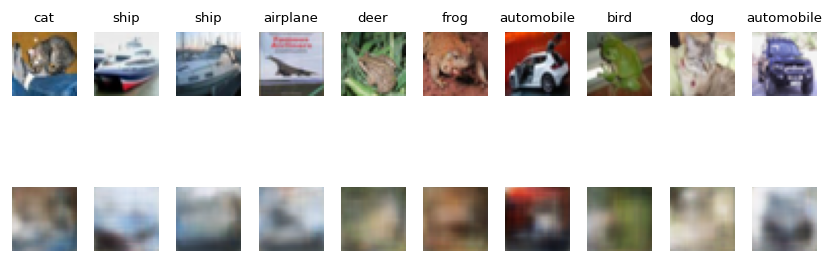

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Predict reconstructed images and class labels
decoded_imgs, predicted_labels = model.predict(x_test[:10])

# Define CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Set up the figure
plt.figure(figsize=(7, 3.5), dpi=120)

for i in range(10):
    # Row 1: Class Label (as Title above original image)
    ax = plt.subplot(2, 10, i + 1)
    predicted_class = np.argmax(predicted_labels[i])
    plt.imshow(x_test[i])
    plt.title(class_names[predicted_class], fontsize=8)
    plt.axis('off')

    # Row 2: Reconstructed Image
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [24]:

from tensorflow.keras import backend as K

# --- Compression Ratio Calculation (unchanged) ---
from tensorflow.keras.models import Model
latent_model = Model(inputs=model.input, outputs=model.get_layer('latent_space').output)

latent_output = latent_model.predict(x_test[:1])
latent_shape = latent_output.shape[1:]

compressed = np.prod(latent_shape)
original = 32 * 32 * 3

print(f'Original size: {original} bytes')
print(f'Compressed size: {compressed} bytes')
print(f'Latent space shape: {latent_shape}')
# the latent space shape is (1, 4, 4, 8) for CIFAR-10 and it means that the latent space has 4x4=16 pixels and each pixel has 8 channels (depth)
print(f'Compression ratio: {original/compressed:.2f}:1')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Original size: 3072 bytes
Compressed size: 128 bytes
Latent space shape: (4, 4, 8)
Compression ratio: 24.00:1


In [25]:
# Load and prepare image
from tensorflow.keras.preprocessing import image

img_path = r"C:\Users\mhmd2\Downloads\c1.jpeg"
original_img = image.load_img(img_path)
original_array = image.img_to_array(original_img).astype('float32') / 255.


In [26]:
# Resize for model input
model_input_img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(model_input_img).astype('float32') / 255.
img_array = np.expand_dims(img_array, axis=0)

print("Input shape for model:", img_array.shape)

# Predict reconstructed image
reconstructed_img, predicted_label = model.predict(img_array)


predicted_class_index = np.argmax(predicted_label)
predicted_class_name = class_names[predicted_class_index]

Input shape for model: (1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


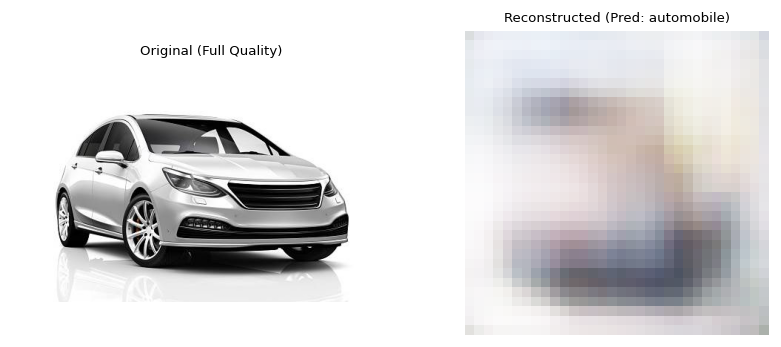

In [27]:
# Show original + reconstructed + predicted label
plt.figure(figsize=(7, 3), dpi=120)

plt.subplot(1, 2, 1)
plt.imshow(original_array / np.max(original_array))
plt.title('Original (Full Quality)', fontsize=8)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img[0], interpolation='nearest')
plt.title(f'Reconstructed (Pred: {predicted_class_name})', fontsize=8)
plt.axis('off')

plt.tight_layout()
plt.show()


In [28]:
img_path = r"C:\Users\mhmd2\Pictures\Camera Roll\ChatGPT Image Apr 2, 2025, 03_44_01 PM.png"  # Notice the r for raw string
img = image.load_img(img_path, target_size=(32, 32))  # Resize to 32x32 

In [29]:
# Load full-size original image for display
original_img = image.load_img(img_path)
original_array = image.img_to_array(original_img).astype('float32') / 255.


In [30]:

# Load a second copy, resized to 32x32 for the model
model_input_img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(model_input_img).astype('float32') / 255.
img_array = np.expand_dims(img_array, axis=0)

print("Input shape for model:", img_array.shape)

Input shape for model: (1, 32, 32, 3)


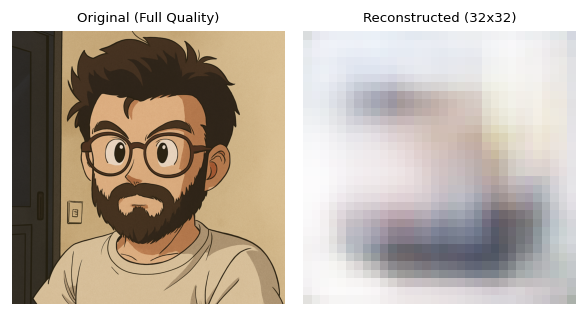

In [32]:
# Display: original (full quality) vs reconstructed (32x32)
plt.figure(figsize=(5, 3), dpi=120)

plt.subplot(1, 2, 1)
plt.imshow(original_array / np.max(original_array))
plt.title('Original (Full Quality)', fontsize=8)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img[0], interpolation='nearest')
plt.title('Reconstructed (32x32)', fontsize=8)
plt.axis('off')

plt.tight_layout()
plt.show()



In [ ]:
# from tensorflow.keras.models import Model
# # Create encoder model
# encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('latent_space').output)

In [ ]:
# # Pick one test image
# test_img = x_test[0:1]  # Shape (1, 32, 32, 3)

# # Compress it
# compressed = encoder.predict(test_img)  # Output (1, 4, 4, 8)

# # Flatten the compressed representation
# compressed_flat = compressed.flatten()

# # Save the compressed vector to a .npy file
# np.save("compressed_image.npy", compressed_flat)

# print("Compressed image saved to compressed_image.npy")


In [ ]:
# import zipfile

# with zipfile.ZipFile('compressed_image.zip', 'w') as zipf:
#     zipf.write('compressed_image.npy')

# print("Compressed image zipped to compressed_image.zip")
